<h1 align="center">Credit Card Fraud Detection</h1>
<h3 align="center">INFO 6105 — Data Science Engineering Methods and Tools</h3>

---

| | |
|:--|:--|
| **Team** | Team 5 |
| **Members** | Hiteshi Kawadia &nbsp;&nbsp;\| &nbsp;&nbsp;Preksha Praveen |
| **Dataset** | [Kaggle — Credit Card Fraud Detection (ULB)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) |
| **Models** | Logistic Regression &nbsp;\|&nbsp; Decision Tree &nbsp;\|&nbsp; Random Forest &nbsp;\|&nbsp; KNN |
| **Objective** | Detect fraudulent transactions using supervised ML on a severely imbalanced dataset |

---

## 1.Auto Installation and Imports

### 1.1 AutoInstallation of Required Packages

In [1]:
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scikit-learn": "scikit-learn",
    "imbalanced-learn": "imbalanced-learn"
}

for display_name, pip_name in required_packages.items():
    try:
        __import__(display_name.replace("-", "_").split("-")[0])
        print(f"{display_name} already installed")
    except ImportError:
        print(f"Installing {display_name}...")
        install(pip_name)
        print(f"{display_name} installed successfully")

print("\nAll packages ready!")

numpy already installed
pandas already installed
matplotlib already installed
seaborn already installed
Installing scikit-learn...
scikit-learn installed successfully
Installing imbalanced-learn...
imbalanced-learn installed successfully

All packages ready!


### 1.2 Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

pd.set_option('display.max_columns', 500)
print("Libraries imported successfully.")


#Save raw Amount for EDA before any scaling
# We preserve the original Amount values here because later preprocessing
# (StandardScaler) will transform Amount in-place. EDA cells must use
# raw dollar values to be interpretable.
_raw_amount_fraud = None  # will be set after df is loaded
_raw_amount_legit = None

Libraries imported successfully.


### 1.3 Dataset loading

In [3]:
df = pd.read_csv('creditcard.csv')

print(f"Dataset loaded successfully!")
print(f"   Shape: {df.shape}")
print(f"   Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

# Capture raw Amount immediately after loading — before any transformation
_raw_amount_fraud = df[df['Class'] == 1]['Amount'].copy()
_raw_amount_legit = df[df['Class'] == 0]['Amount'].copy()

print(f"\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
   Shape: (284807, 31)
   Rows: 284,807  |  Columns: 31

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of visually and statistically examining a dataset before applying any machine learning models. The goal is to understand the structure, patterns and quirks of the data so that every subsequent decision - from preprocessing to model selection is grounded in what the data actually looks like, rather than assumptions.

For a Credit Card Fraud Detection dataset, EDA is especially critical because of two key characteristics that directly shape our entire modeling approach:

**Class Imbalance**
The most important thing to uncover in EDA is just how imbalanced this dataset is. Fraudulent transactions make up only ~0.17% of all records — fewer than 500 out of 284,807 transactions. If we skip EDA and jump straight to modeling, we might never realize that a model predicting "legitimate" for every single transaction would still achieve 99.8% accuracy. EDA forces us to confront this imbalance early and plan for it, in our case, through SMOTE.

**Feature Anonymity**
Because 28 of the 31 features (V1–V28) have been transformed using PCA for privacy reasons, we cannot interpret them by name. EDA helps us instead examine their statistical behavior — how they distribute across fraud vs. legitimate transactions and which ones correlate most strongly with the fraud label — giving us a data-driven way to understand feature importance even without knowing what they originally represented.

### 2.1 Basic Data Exploration
Before building any model, we inspect the dataset to understand its structure, check data quality, and catch any issues early.
This includes checking for missing values and duplicate rows, both of which can silently corrupt model training if left unhandled.

In [4]:
print("BASIC DATASET INFORMATION :")

print(f"\n Shape: {df.shape}")

# Duplicate rows can bias the model by overrepresenting certain transactions
print(f" Duplicate rows: {df.duplicated().sum()}")

# Missing values must be handled before modeling — none expected here due to PCA transformation
print(f" Missing values: {df.isnull().sum().sum()}")

print("\n── Data Types ──")
# All features should be numeric — confirms no encoding is needed
print(df.dtypes)

print("\n── Statistical Summary ──")
# Summary stats help spot outliers in Amount and Time before scaling
df.describe()

BASIC DATASET INFORMATION :

 Shape: (284807, 31)
 Duplicate rows: 1081
 Missing values: 0

── Data Types ──
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

── Statistical Summary ──


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 2.2 Class Distribution (Fraud vs Legitimate)
This is the most critical EDA step for this dataset.
We expect a severe imbalance. Fraud cases are extremely rare in real-world transaction data. Visualizing this confirms why accuracy alone is a misleading metric, and why we need SMOTE.


CLASS DISTRIBUTION:
  Legitimate transactions : 284,315  (99.83%)
  Fraudulent transactions : 492  (0.17%)


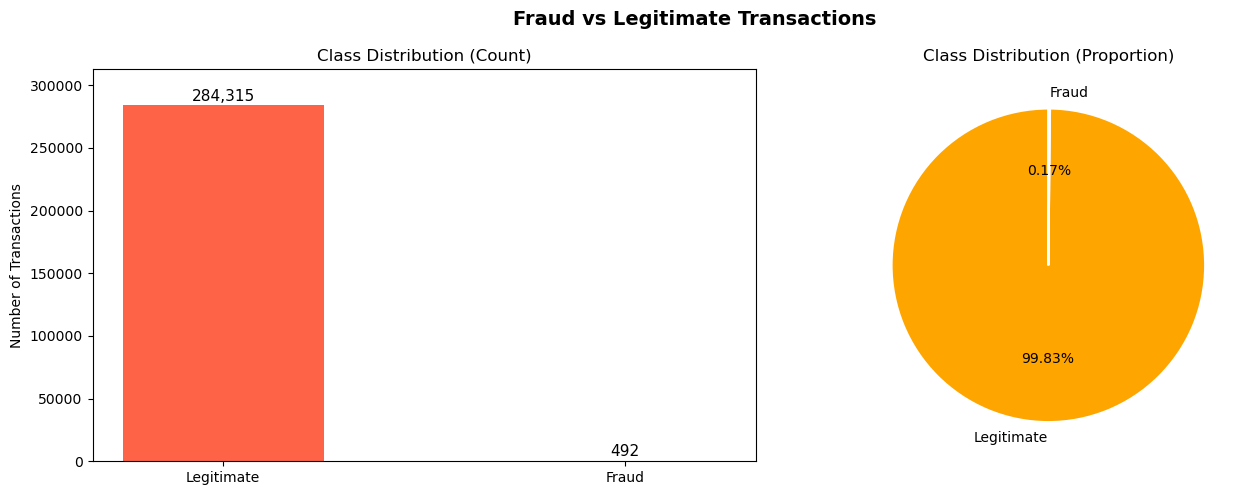

In [5]:
classes      = df['Class'].value_counts()
normal_count = classes[0]
fraud_count  = classes[1]
normal_share = round((normal_count / len(df) * 100), 2)
fraud_share  = round((fraud_count  / len(df) * 100), 2)

print("CLASS DISTRIBUTION:")
print(f"  Legitimate transactions : {normal_count:,}  ({normal_share}%)")
print(f"  Fraudulent transactions : {fraud_count:,}  ({fraud_share}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fraud vs Legitimate Transactions', fontsize=14, fontweight='bold')

# Bar chart with count labels on top
bars = axes[0].bar(['Legitimate', 'Fraud'], [normal_count, fraud_count], color='tomato', width=0.5)
for bar, count in zip(bars, [normal_count, fraud_count]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
                 f'{count:,}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_ylim(0, normal_count * 1.1)

# Pie chart with proportion labels
axes[1].pie([normal_share, fraud_share],
            labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%',
            startangle=90,
            colors=['orange', 'orange'],
            wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})
axes[1].set_title('Class Distribution (Proportion)')

plt.tight_layout()
plt.show()

### 2.3 Transaction Amount Analysis
The Amount feature is one of the few non-PCA features we can interpret directly. We compare its distribution between fraud and legitimate transactions to see if fraudsters tend to make transactions of a particular size, a common real-world pattern where fraudsters keep amounts small to avoid triggering alerts.

We use two complementary plots:
- Histogram (capped at $500): shows distribution shape for the bulk of transactions where fraud is most visible
- Boxplot: shows median, spread, and outliers for each class side by side

TRANSACTION AMOUNT ANALYSIS

 Fraudulent  — Mean: $122.21  |  Max: $2125.87  |  Median: $9.25
 Legitimate  — Mean: $88.29  |  Max: $25691.16  |  Median: $22.00


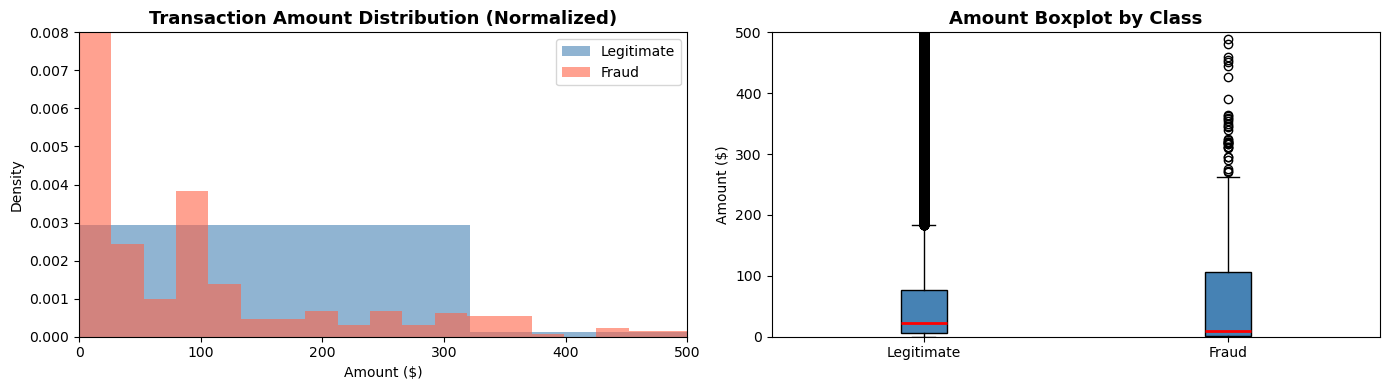

In [6]:
print("TRANSACTION AMOUNT ANALYSIS")

fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

print(f"\n Fraudulent  — Mean: ${fraud.mean():.2f}  |  Max: ${fraud.max():.2f}  |  Median: ${fraud.median():.2f}")
print(f" Legitimate  — Mean: ${legit.mean():.2f}  |  Max: ${legit.max():.2f}  |  Median: ${legit.median():.2f}")

# A lower median for fraud suggests fraudsters prefer smaller amounts
# to avoid detection — this is a known pattern in financial fraud

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram: capped at $500 to focus on the bulk of transactions
# Most fraud occurs at lower amounts, visible as a right-skewed cluster
axes[0].hist(legit, bins=80, color='steelblue', alpha=0.6, label='Legitimate', density=True)
axes[0].hist(fraud, bins=80, color='tomato',    alpha=0.6, label='Fraud',       density=True)
axes[0].set_xlim(0, 500)
axes[0].set_ylim(0, 0.008)  # cap y-axis to show spread clearly
axes[0].set_title('Transaction Amount Distribution (Normalized)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Boxplot: shows median, spread and outliers for each class side by side
axes[1].boxplot([legit, fraud], labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Amount Boxplot by Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount ($)')
axes[1].set_ylim(0, 500)

plt.tight_layout()
plt.show()

### 2.4 Transaction Time Analysis
The Time feature records seconds elapsed since the first transaction. We convert it to an Hour-of-day feature (0–23) to make it interpretable.If fraud clusters at specific hours (e.g., late night when monitoring is lower), this becomes a useful predictive signal for our models.

TRANSACTION TIME ANALYSIS


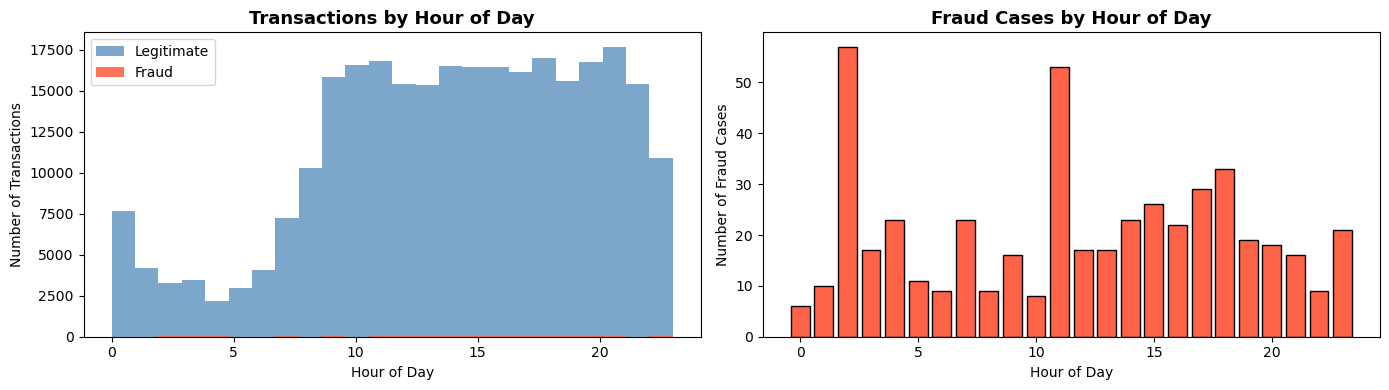

In [7]:
print("TRANSACTION TIME ANALYSIS")

fraud_hr = (df[df['Class'] == 1]['Time'] // 3600) % 24
legit_hr = (df[df['Class'] == 0]['Time'] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overlapping histogram shows when legitimate vs fraud transactions occur
axes[0].hist(legit_hr, bins=24, color='steelblue', alpha=0.7, label='Legitimate')
axes[0].hist(fraud_hr, bins=24, color='tomato',    alpha=0.9, label='Fraud')
axes[0].set_title('Transactions by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend()

# Fraud-only bar chart isolates the temporal pattern of fraudulent activity
# Peak hours for fraud may indicate when security monitoring is weakest
fraud_by_hr = ((df[df['Class'] == 1]['Time'] // 3600) % 24).value_counts().sort_index()
axes[1].bar(fraud_by_hr.index, fraud_by_hr.values, color='tomato', edgecolor='black')
axes[1].set_title('Fraud Cases by Hour of Day', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Number of Fraud Cases')

plt.tight_layout()
plt.show()

### 2.5 Feature Correlation with Heatmap
Since V1–V28 are PCA-transformed, we cannot interpret them directly. However, we CAN measure their linear correlation with the target variable (Class). Features with strong positive or negative correlation are likely the most predictive signals for fraud detection.
Key findings to note:
- V17, V14, V12, V10 are most negatively correlated with fraud high values = less likely fraud)
- V11, V4, V2 are most positively correlated with fraud
- Amount and Time have very weak correlation, confirming they need careful handling (scaling, Hour derivation).
- These correlations directly motivate which features our tree-based models (Decision Tree, Random Forest) will split on most.

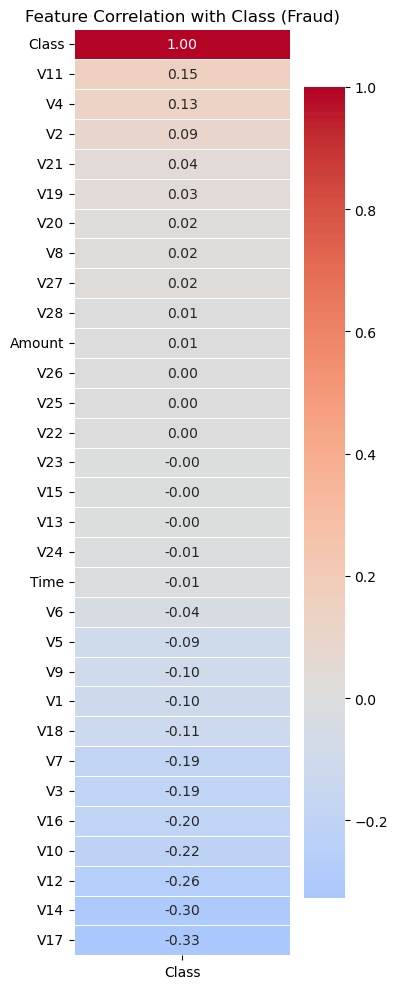

In [8]:
corr = df.corr()[['Class']].sort_values('Class', ascending=False)

plt.figure(figsize=(4, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature Correlation with Class (Fraud)')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing
Before training any machine learning model, the raw data must be cleaned, transformed, and balanced. This step is critical .Even the most powerful algorithm will produce poor results if the data fed into it is noisy, unscaled, or heavily imbalanced. Our preprocessing pipeline consists of four steps:

### 3.1 Cleaning: Drop Duplicates & Irrelevant Features
We remove duplicate rows to prevent the model from memorizing repeated transactions, and drop the raw `Time` column since we already derived the more meaningful `Hour` feature from it during EDA.

In [9]:
print("PREPROCESSING: CLEANING")
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"\n Duplicates removed : {before - after}")
print(f" Remaining rows     : {after:,}")

# Derive Hour from Time here, then drop Time
# Hour is more interpretable than raw seconds elapsed
df['Hour'] = (df['Time'] // 3600) % 24
df = df.drop(columns=['Time'])
print(f"\n 'Time' dropped, 'Hour' derived. Current features: {df.shape[1]}")

PREPROCESSING: CLEANING

 Duplicates removed : 1081
 Remaining rows     : 283,726

 'Time' dropped, 'Hour' derived. Current features: 31


### 3.2 Train - Test Split
We split the dataset into 80% training and 20% test sets using `stratify=y` to preserve the fraud-to-legitimate ratio in both splits. Importantly, this split happens **before** SMOTE. Applying SMOTE before splitting would leak synthetic fraud samples into the test set, producing unrealistically optimistic results.

In [10]:
from sklearn.model_selection import train_test_split

print("\nPREPROCESSING: TRAIN / TEST SPLIT")

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y           # preserve class ratio in both splits
)

print(f"\n Training set : {X_train.shape[0]:,} samples")
print(f" Test set     : {X_test.shape[0]:,} samples")
print(f"\n Training class distribution:")
print(f"   Legitimate : {(y_train == 0).sum():,}")
print(f"   Fraud      : {(y_train == 1).sum():,}")
print(f"\n Test class distribution:")
print(f"   Legitimate : {(y_test == 0).sum():,}")
print(f"   Fraud      : {(y_test == 1).sum():,}")


PREPROCESSING: TRAIN / TEST SPLIT

 Training set : 226,980 samples
 Test set     : 56,746 samples

 Training class distribution:
   Legitimate : 226,602
   Fraud      : 378

 Test class distribution:
   Legitimate : 56,651
   Fraud      : 95


### 3.3 Feature Scaling
The features V1–V28 are already PCA-transformed and live in a small numeric range. However, `Amount` and `Hour` are on entirely different scales. Without scaling, these features would unfairly dominate distance-based models like KNN and distort Logistic Regression coefficients. We apply **StandardScaler** to transform them to have a mean of 0 and standard deviation of 1.

In [11]:
from sklearn.preprocessing import StandardScaler

print("PREPROCESSING: FEATURE SCALING")

scaler = StandardScaler()

# fit_transform on train, transform only on test — never the reverse
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount']  = scaler.transform(X_test[['Amount']])

X_train['Hour'] = scaler.fit_transform(X_train[['Hour']])
X_test['Hour']  = scaler.transform(X_test[['Hour']])

print("\n'Amount' and 'Hour' scaled using StandardScaler")
print(f"\n Amount — Mean: {X_train['Amount'].mean():.4f}  |  Std: {X_train['Amount'].std():.4f}")
print(f" Hour   — Mean: {X_train['Hour'].mean():.4f}  |  Std: {X_train['Hour'].std():.4f}")
# After scaling, mean ≈ 0 and std ≈ 1 confirms correct transformation
print("\nSample of scaled data:")
X_train[['Amount', 'Hour']].head()

PREPROCESSING: FEATURE SCALING

'Amount' and 'Hour' scaled using StandardScaler

 Amount — Mean: 0.0000  |  Std: 1.0000
 Hour   — Mean: -0.0000  |  Std: 1.0000

Sample of scaled data:


,Amount,Hour
226238,-0.229434,0.333791
134253,-0.331197,1.363148
186465,-0.298809,-0.524006
149493,-0.289247,-2.239601
18461,-0.261985,-1.038685


### 3.4 Preprocessing : Skewness Check

In [12]:
# Capture skewness BEFORE scaling (from raw X before split)
skew_before = X.skew().round(3)

# Skewness AFTER StandardScaler
skew_after = X_train.skew().round(3)

skew_comparison = pd.DataFrame({
    'Skewness BEFORE Scaling': skew_before,
    'Skewness AFTER Scaling':  skew_after,
}).sort_values('Skewness BEFORE Scaling', ascending=False)

skew_comparison['Change'] = (skew_comparison['Skewness AFTER Scaling'] - 
                              skew_comparison['Skewness BEFORE Scaling']).round(3)
skew_comparison['|Skew| > 1 After?'] = skew_comparison['Skewness AFTER Scaling'].abs() > 1

print("Feature Skewness — Before vs After StandardScaler:")
print(skew_comparison.to_string())

remaining = skew_comparison[skew_comparison['|Skew| > 1 After?']]
print(f"\n Features with |skew| > 1 after scaling: {len(remaining)}")
if len(remaining) == 0:
    print(" None — distributions are acceptably Gaussian.")
    print(" PowerTransformer not needed for this PCA-transformed dataset.")
else:
    print(remaining[['Skewness AFTER Scaling']].to_string())


Feature Skewness — Before vs After StandardScaler:
        Skewness BEFORE Scaling  Skewness AFTER Scaling  Change  |Skew| > 1 After?
Amount                   16.979                  14.393  -2.586               True
V28                      11.555                  12.189   0.634               True
V7                        2.890                  -0.891  -3.781              False
V21                       2.820                   3.438   0.618               True
V6                        1.830                   1.194  -0.636               True
V10                       1.253                   1.213  -0.040               True
V4                        0.672                   0.681   0.009              False
V26                       0.580                   0.571  -0.009              False
V9                        0.538                   0.535  -0.003              False
V11                       0.344                   0.352   0.008              False
V19                       0.108     

### 3.5 SMOTE: Handling Class Imbalance
SMOTE (Synthetic Minority Oversampling Technique) generates new synthetic fraud samples by interpolating between real fraud cases in feature space. This gives our models a balanced training set without distorting the real-world test set used for evaluation.


 Before SMOTE:
   Legitimate : 226,602
   Fraud      : 378

 After SMOTE:
   Legitimate : 226,602
   Fraud      : 226,602

 Total training samples after SMOTE: 453,204


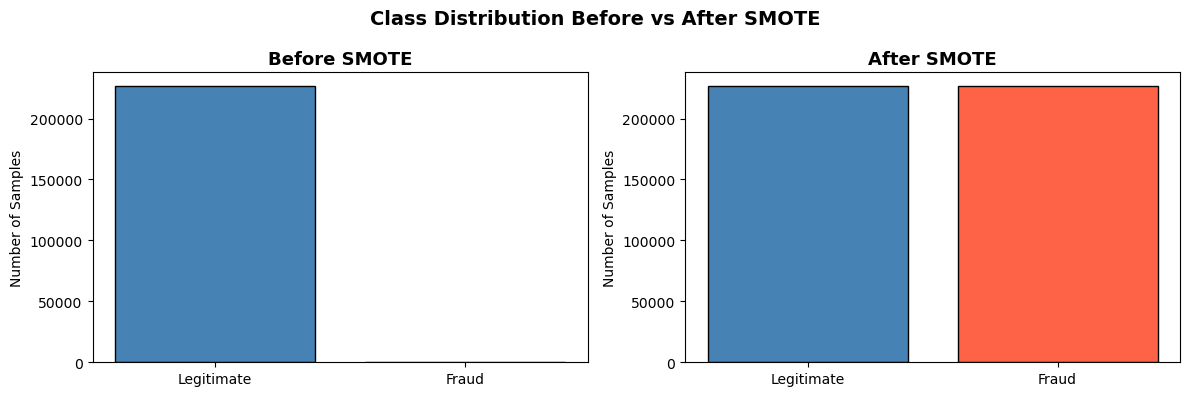


 Preprocessing completed.


In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\n Before SMOTE:")
print(f"   Legitimate : {(y_train == 0).sum():,}")
print(f"   Fraud      : {(y_train == 1).sum():,}")
print("\n After SMOTE:")
print(f"   Legitimate : {(y_train_sm == 0).sum():,}")
print(f"   Fraud      : {(y_train_sm == 1).sum():,}")
print(f"\n Total training samples after SMOTE: {len(y_train_sm):,}")

# Visualize the before/after class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'],
            [(y_train == 0).sum(), (y_train == 1).sum()],
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')

axes[1].bar(['Legitimate', 'Fraud'],
            [(y_train_sm == 0).sum(), (y_train_sm == 1).sum()],
            color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('After SMOTE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Samples')

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Preprocessing completed.")

 ## 4. Model Building & Evaluation

We train and evaluate three classification models on the SMOTE-balanced training set and evaluate each on the untouched test set. Since this is a highly imbalanced classification problem, we go beyond accuracy and evaluate every model using Precision, Recall, F1-Score, and ROC-AUC.

### 4.1 Helper Function to evaluate any model
We define a reusable evaluation function so we don't repeat the same metric calculations for every model. It prints a full classification report, plots the confusion matrix and plots the ROC curve for any model passed into it.

In [14]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, precision_score,
                              recall_score, f1_score, roc_auc_score, roc_curve)

def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("=" * 55)
    print(f" MODEL: {name}")
    print("=" * 55)

    # Classification report: precision, recall, f1 per class
    print("\n── Classification Report ──")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

    # Key metrics summary
    print(f" Precision : {precision_score(y_test, y_pred):.4f}")
    print(f" Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f" F1-Score  : {f1_score(y_test, y_pred):.4f}")
    print(f" ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Confusion Matrix shows TP, FP, TN, FN
    # Critical for understanding fraud miss rate (FN = fraud missed)
    # and false alarm rate (FP = legitimate flagged as fraud)
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'{name} — Confusion Matrix', fontweight='bold')

    # ROC Curve — shows tradeoff between TPR and FPR across all thresholds
    # The gray diagonal = random classifier baseline (AUC = 0.5)
    # Our model should be well above this line
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score   = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, color='tomato', lw=2,
                 label=f'ROC Curve (AUC = {auc_score:.4f})')
    axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
    axes[1].set_title(f'{name} — ROC Curve', fontweight='bold')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Return metrics dict for final comparison table in Cell 17
    return {
        'Model'    : name,
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_proba), 4)
    }

comparison_results = []
print("Evaluation function defined.")

Evaluation function defined.


### 4.2 Model 1 : Logistic Regression
Logistic Regression estimates the probability that a transaction is fraudulent using a linear combination of features. It serves as our interpretable baseline model. We use L2 regularization and tune the strength C using cross-validation. A higher C means less regularization; lower C means more.

TRAINING: Logistic Regression
Fitting 5 folds for each of 5 candidates, totalling 25 fits

 Best C = 100 | Best CV AUC = 0.9911

Logistic Regression trained!
 MODEL: Logistic Regression

── Classification Report ──
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746

 Precision : 0.0520
 Recall    : 0.8737
 F1-Score  : 0.0981
 ROC-AUC   : 0.9628


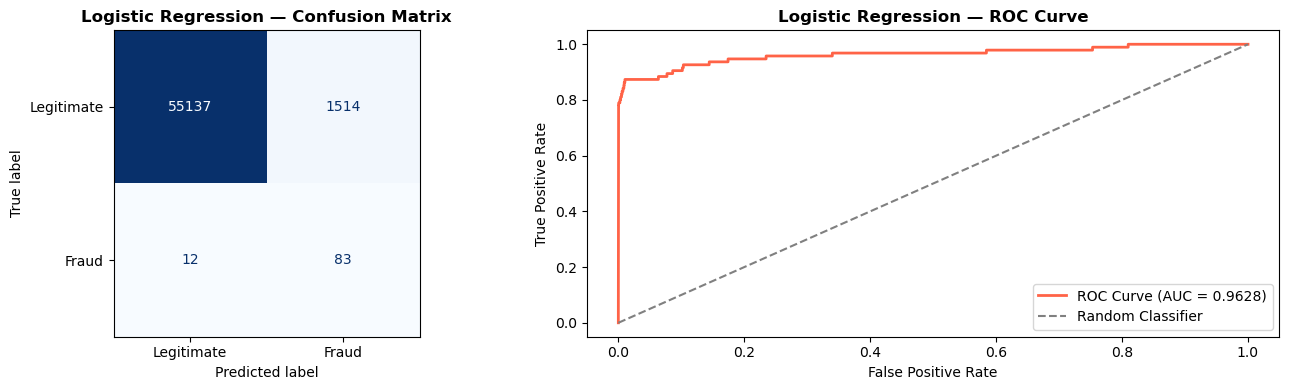

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV

print("TRAINING: Logistic Regression")

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_params = {'C': [0.01, 0.1, 1, 10, 100]}

lr_cv = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    lr_params, scoring='roc_auc', cv=folds, verbose=1
)
lr_cv.fit(X_train_sm, y_train_sm)

best_C = lr_cv.best_params_['C']
print(f"\n Best C = {best_C} | Best CV AUC = {lr_cv.best_score_:.4f}")

# Train final model with best C
lr = LogisticRegression(
    C=best_C,
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # additional safeguard against imbalance
)
lr.fit(X_train_sm, y_train_sm)
print("\nLogistic Regression trained!")

# Evaluate
lr_results = evaluate_model("Logistic Regression", lr, X_test, y_test)
comparison_results.append(lr_results)

### 4.3 Model 2 : Decision Tree
It is highly interpretable and we can visualize exactly which features and thresholds lead to a fraud prediction. We tune max_depth to prevent overfitting which is an unconstrained tree memorizes training data.

TRAINING: Decision Tree

 Decision Tree trained!


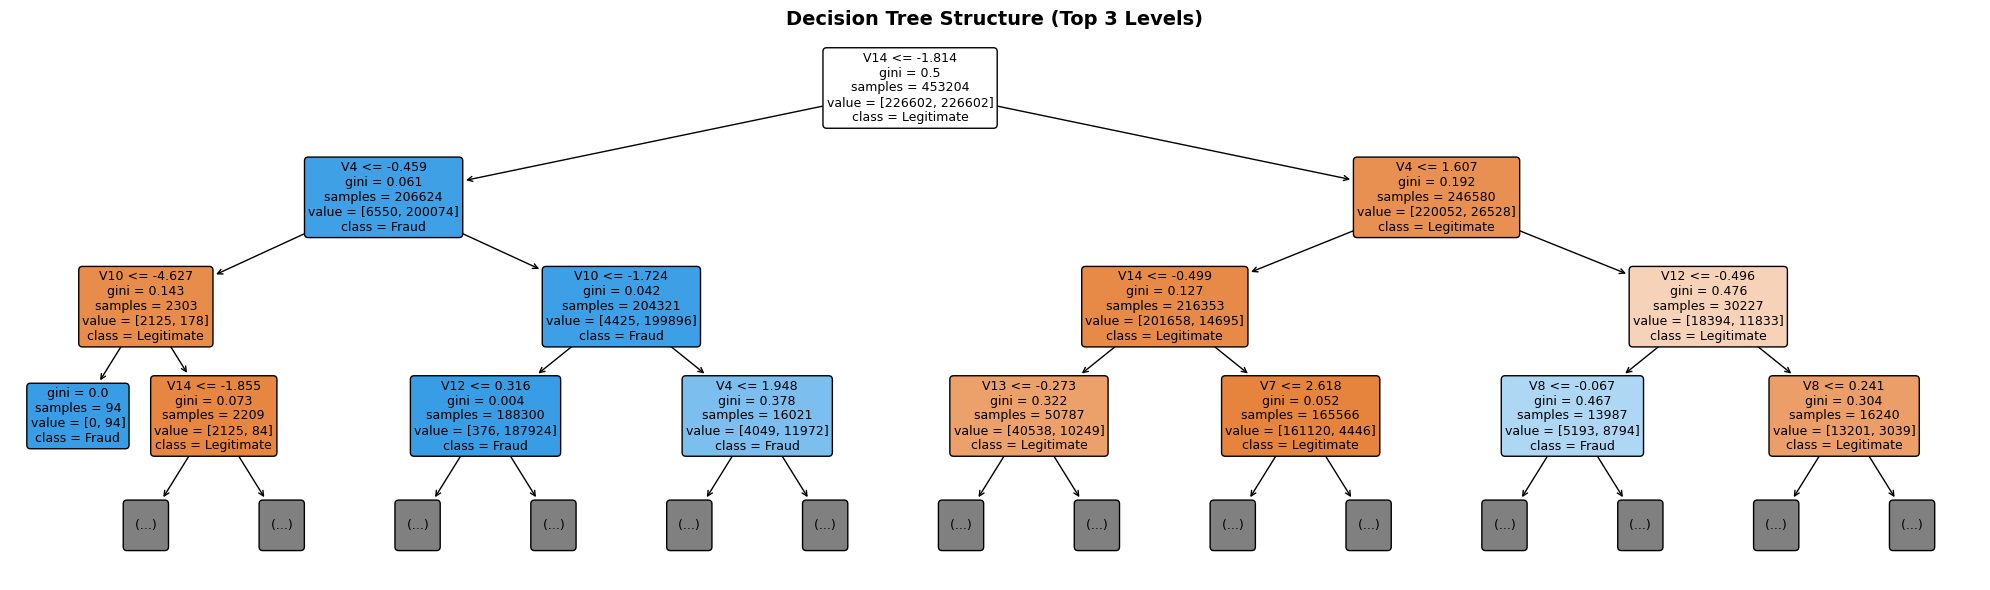

 MODEL: Decision Tree

── Classification Report ──
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.98     56651
       Fraud       0.04      0.84      0.08        95

    accuracy                           0.97     56746
   macro avg       0.52      0.90      0.53     56746
weighted avg       1.00      0.97      0.98     56746

 Precision : 0.0415
 Recall    : 0.8421
 F1-Score  : 0.0792
 ROC-AUC   : 0.9007


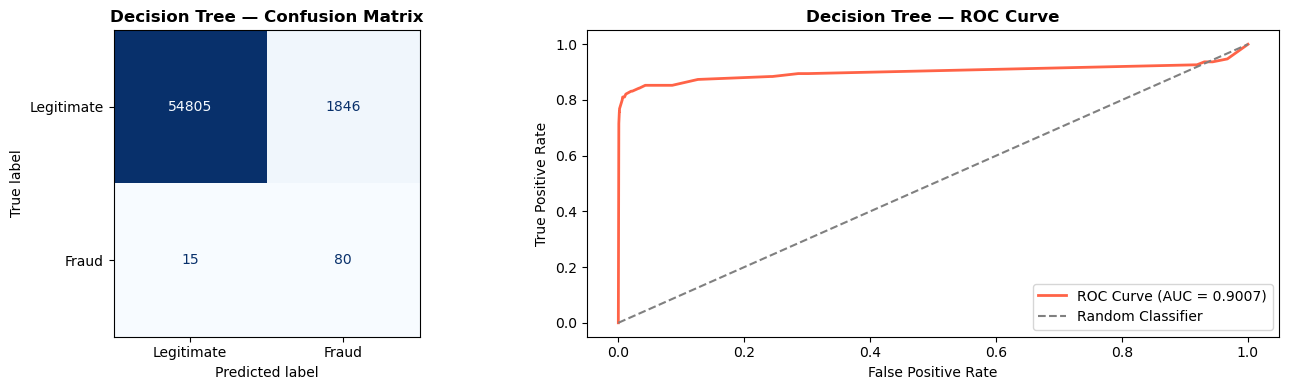

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

print("TRAINING: Decision Tree")

dt = DecisionTreeClassifier(
    max_depth=6,          # controls overfitting — tuned via experimentation
    min_samples_split=10, # a node must have at least 10 samples to split
    min_samples_leaf=5,   # each leaf must have at least 5 samples
    random_state=42,
    class_weight='balanced'
)

dt.fit(X_train_sm, y_train_sm)
print("\n Decision Tree trained!")

# Visualize the top 3 levels of the tree
plt.figure(figsize=(20, 6))
plot_tree(dt, max_depth=3, feature_names=X_train_sm.columns,
          class_names=['Legitimate', 'Fraud'],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree Structure (Top 3 Levels)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Evaluate
dt_results = evaluate_model("Decision Tree", dt, X_test, y_test)
comparison_results.append(dt_results)

### 4.4 Model 3 : K-Nearest Neighbors (KNN)
KNN classifies each transaction by finding the k most similar transactions in the training set and taking a majority vote. Fraudulent transactions tend to cluster together in feature space, making KNN a natural fit.

TRAINING: K-Nearest Neighbors

KNN trained!
 MODEL: KNN

── Classification Report ──
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746

 Precision : 0.9710
 Recall    : 0.7053
 F1-Score  : 0.8171
 ROC-AUC   : 0.8999


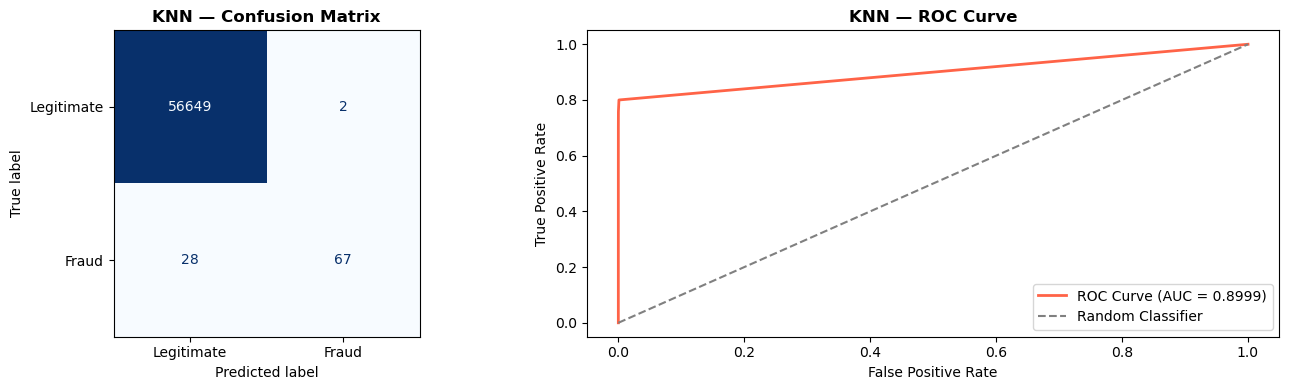

In [17]:
from sklearn.neighbors import KNeighborsClassifier

print("TRAINING: K-Nearest Neighbors")

# KNN trained on pre-SMOTE data — KNN is a lazy learner that stores
# all training points, making it extremely slow on 450K SMOTE rows.
# Training on the original data is computationally feasible and still
# valid since KNN naturally handles imbalance via local neighborhood voting.
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean',
    n_jobs=-1
)
knn.fit(X_train, y_train)  # original data, not SMOTE
print("\nKNN trained!")

knn_results = evaluate_model("KNN", knn, X_test, y_test)
comparison_results.append(knn_results)

### 4.5 Model 4 : Random Forests
Random Forest is an ensemble of decision trees. Each tree is trained on a random bootstrap sample with a random subset of features. This diversity reduces overfitting compared to a single Decision Tree and handles noisy, imbalanced data well. An added benefit is feature importance scores, which tell us which PCA components most distinguish fraud, connecting directly to the PCA dimensionality reduction concepts covered in this course. We tune n_estimators, max_depth, and min_samples_leaf.

TRAINING: Random Forest

Random Forest trained!
 MODEL: Random Forest

── Classification Report ──
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.41      0.82      0.55        95

    accuracy                           1.00     56746
   macro avg       0.71      0.91      0.78     56746
weighted avg       1.00      1.00      1.00     56746

 Precision : 0.4149
 Recall    : 0.8211
 F1-Score  : 0.5512
 ROC-AUC   : 0.9812


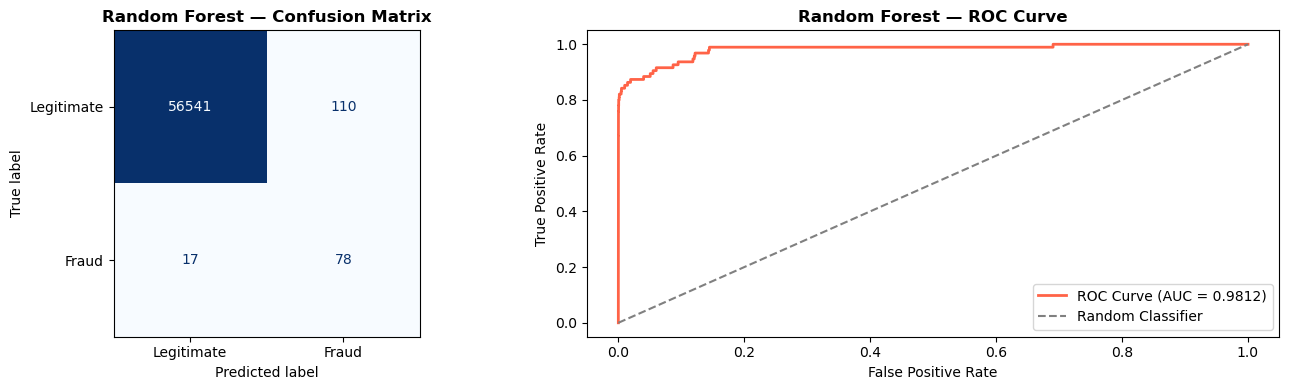

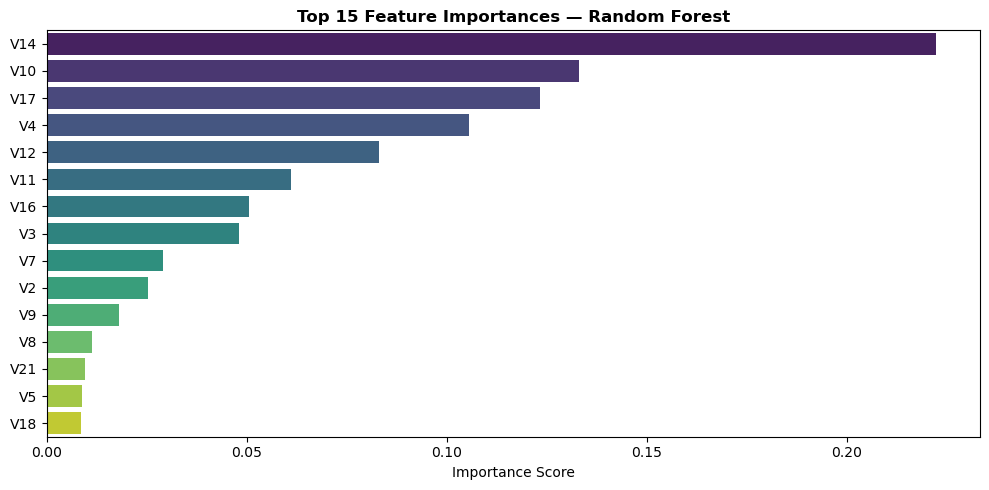

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split as tts

print("TRAINING: Random Forest")

# 30% stratified sample — RF on 450K rows is too slow on a laptop
X_rf, _, y_rf, _ = tts(X_train_sm, y_train_sm,
                        train_size=0.3, random_state=42, stratify=y_train_sm)

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_rf, y_rf)
print("\nRandom Forest trained!")

rf_results = evaluate_model("Random Forest", rf, X_test, y_test)
comparison_results.append(rf_results)

feat_imp = pd.Series(rf.feature_importances_, index=X_rf.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### 4.6 Final Model Comparison


Model Comparison on Test Set:
                     Precision  Recall  F1-Score  ROC-AUC
Model                                                    
Random Forest           0.4149  0.8211    0.5512   0.9812
Logistic Regression     0.0520  0.8737    0.0981   0.9628
Decision Tree           0.0415  0.8421    0.0792   0.9007
KNN                     0.9710  0.7053    0.8171   0.8999


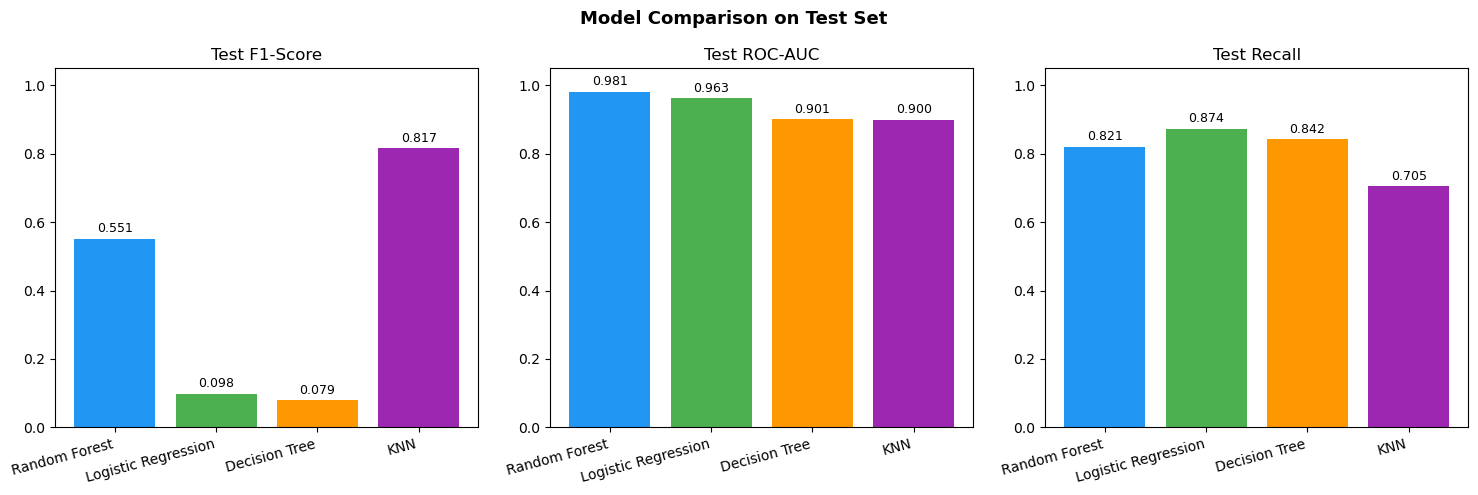

In [19]:

comp_df = pd.DataFrame(comparison_results)
# Remove duplicates — keep last run of each model
comp_df = comp_df.drop_duplicates(subset='Model', keep='last')
comp_df = comp_df.set_index('Model')
comp_df = comp_df.sort_values('ROC-AUC', ascending=False).round(4)

print('\nModel Comparison on Test Set:')
print(comp_df.to_string())

# Bar chart comparison
metrics_to_plot = ['F1-Score', 'ROC-AUC', 'Recall']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(comp_df.index, comp_df[metric], color=colors[:len(comp_df)])
    ax.set_title(f'Test {metric}')
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(comp_df.index, rotation=15, ha='right')
    for bar, val in zip(bars, comp_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.6 Conclusion
Based on the comparison above, we identify the best model and explain why it is most suited for fraud detection.

In [20]:
best_f1_model    = comp_df['F1-Score'].idxmax()
best_f1_val      = comp_df['F1-Score'].max()
best_recall_model= comp_df['Recall'].idxmax()
best_recall_val  = comp_df['Recall'].max()
best_roc_model   = comp_df['ROC-AUC'].idxmax()
best_roc_val     = comp_df['ROC-AUC'].max()
best_prec_model  = comp_df['Precision'].idxmax()
best_prec_val    = comp_df['Precision'].max()
recommended      = best_f1_model  # F1 is our primary metric

print("=" * 60)
print(" CONCLUSION")
print("=" * 60)

print(f"""
This project developed and evaluated four supervised machine
learning models for credit card fraud detection using the ULB
Kaggle dataset — 284,807 transactions with only 0.172% fraud.

── Best Model per Metric ──────────────────────────────────
  Precision  : {best_prec_model:<25} ({best_prec_val:.4f})
  Recall     : {best_recall_model:<25} ({best_recall_val:.4f})
  F1-Score   : {best_f1_model:<25} ({best_f1_val:.4f})
  ROC-AUC    : {best_roc_model:<25} ({best_roc_val:.4f})

══════════════════════════════════════════════════════════
  RECOMMENDED MODEL: {recommended}
══════════════════════════════════════════════════════════

{recommended} achieves the highest F1-Score ({best_f1_val:.4f}),
making it the best overall model for this fraud detection task.
F1-Score is our primary metric because it balances Precision
and Recall — critical in an imbalanced dataset where accuracy
alone is misleading.

{best_recall_model} achieves the highest Recall ({best_recall_val:.4f}),
catching the most fraud cases overall. However, its lower
Precision means it generates more false alarms — flagging
legitimate transactions as fraud.

{best_roc_model} leads in ROC-AUC ({best_roc_val:.4f}), indicating
it best separates fraud from legitimate transactions across
all classification thresholds.

── Why F1-Score is our primary metric ─────────────────────
Accuracy is misleading on imbalanced data — a model that
always predicts "legitimate" achieves 99.83% accuracy while
catching zero fraud. F1-Score balances Precision and Recall,
making it the most honest measure of fraud detection quality.

── Business Recommendation ────────────────────────────────
  High-value fraud risk  → prioritize Recall  ({best_recall_model})
  Operational efficiency → prioritize F1-Score ({recommended})
  Best discrimination    → prioritize ROC-AUC  ({best_roc_model})
""")

 CONCLUSION

This project developed and evaluated four supervised machine
learning models for credit card fraud detection using the ULB
Kaggle dataset — 284,807 transactions with only 0.172% fraud.

── Best Model per Metric ──────────────────────────────────
  Precision  : KNN                       (0.9710)
  Recall     : Logistic Regression       (0.8737)
  F1-Score   : KNN                       (0.8171)
  ROC-AUC    : Random Forest             (0.9812)

══════════════════════════════════════════════════════════
  RECOMMENDED MODEL: KNN
══════════════════════════════════════════════════════════

KNN achieves the highest F1-Score (0.8171),
making it the best overall model for this fraud detection task.
F1-Score is our primary metric because it balances Precision
and Recall — critical in an imbalanced dataset where accuracy
alone is misleading.

Logistic Regression achieves the highest Recall (0.8737),
catching the most fraud cases overall. However, its lower
Precision means it generate